<a href="https://colab.research.google.com/github/nihaar06/Deep_Learning/blob/main/CNN/fashion_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout
import numpy as np
from tensorflow.keras.models import Sequential
from keras.utils import to_categorical

In [2]:

 (X_train,y_train),(X_test,y_test)=fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [4]:
y_test[:5]

array([9, 2, 1, 1, 6], dtype=uint8)

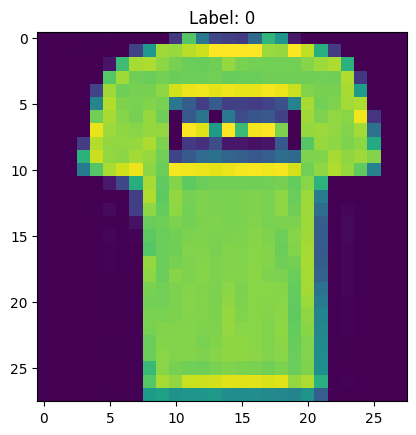

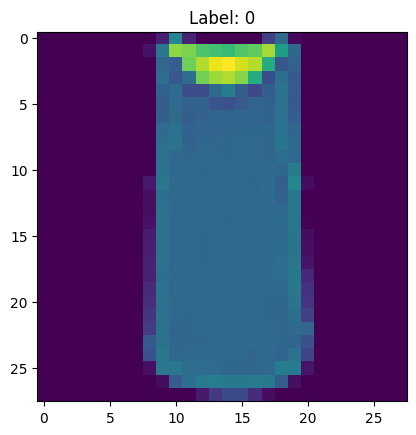

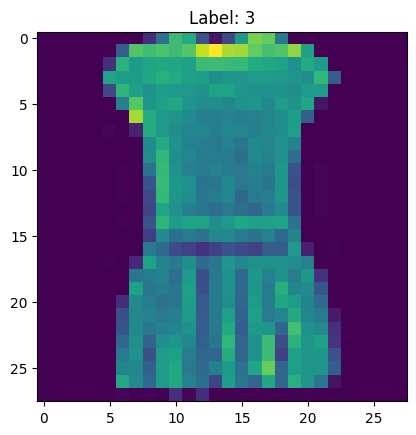

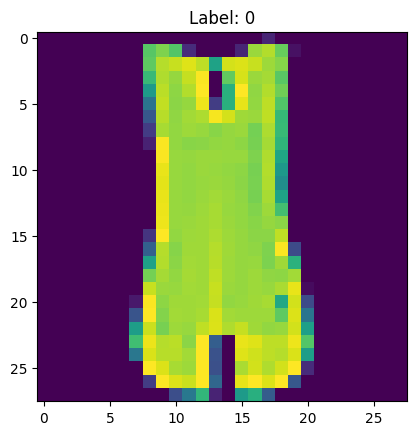

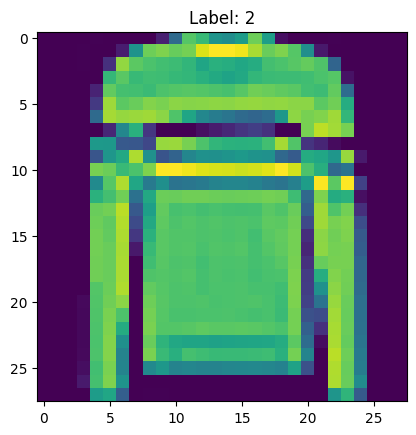

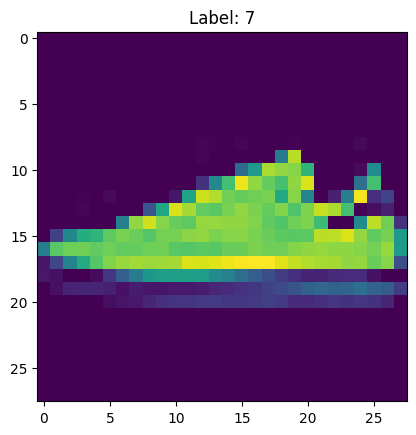

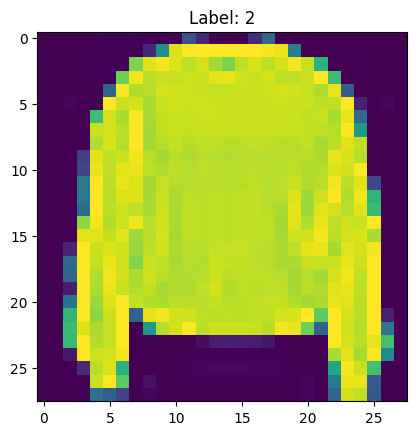

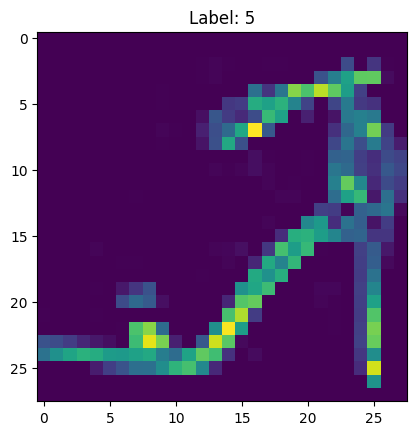

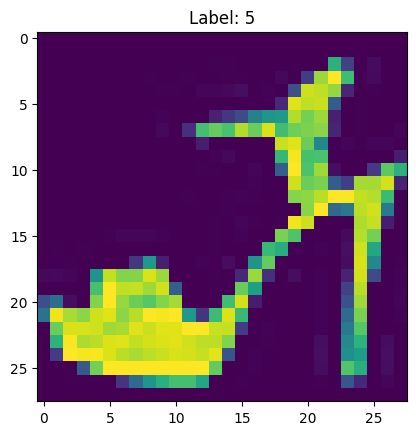

In [5]:
for i in range(1,10):
  img=X_train[i]
  plt.imshow(img)
  label=y_train[i]
  plt.title(f"Label: {label}")
  plt.show()

In [6]:
#number of images in each class


In [7]:
X_train=X_train.reshape(-1,28,28,1).astype('float32')/255
X_test=X_test.reshape(-1,28,28,1).astype('float32')/255

y_train=to_categorical(y_train)
y_test=to_categorical(y_test)

In [8]:
model=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(X_train,y_train,epochs=10,batch_size=64,validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8136 - loss: 0.5135 - val_accuracy: 0.8657 - val_loss: 0.3745
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8779 - loss: 0.3432 - val_accuracy: 0.8881 - val_loss: 0.3204
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8916 - loss: 0.2962 - val_accuracy: 0.8953 - val_loss: 0.2939
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9045 - loss: 0.2623 - val_accuracy: 0.8984 - val_loss: 0.2752
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9122 - loss: 0.2385 - val_accuracy: 0.9075 - val_loss: 0.2575
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9210 - loss: 0.2154 - val_accuracy: 0.9043 - val_loss: 0.2577
Epoch 7/10
209/750 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9282 - loss: 0.1905

In [ ]:
from tensorflow import train
from sklearn.metrics import r2_score,mean_absolute_error,mean_absolute_error
y_pred=model.predict(X_test)
test_loss,test_acc=model.evaluate(X_test,y_test)
train_loss,train_acc=model.evaluate(X_train,y_train)
print("Test Accuracy:",test_acc)
print("Train Accuracy:",train_acc)
print("Test Loss:",test_loss)
print("Train Loss:",train_loss)

In [ ]:
predictions=model.predict(X_test[:5])
op_labels=np.argmax(predictions,axis=1)
t_labels=np.argmax(y_test[:5],axis=1)
for i in range(5):
  plt.imshow(X_test[i])
  plt.title(f"Predicted: {op_labels[i]}, Actual: {t_labels[i]}")
  plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
y_pred_cls=np.argmax(model.predict(X_test),axis=1)
y_true_cls=np.argmax(y_test,axis=1)
sns.heatmap(confusion_matrix(y_pred_cls,y_true_cls),fmt="d",annot=True)

In [ ]:
from keras.src.random import dropout
model2=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax'),
    Dropout(0.5)
])

In [ ]:
model2.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history=model2.fit(X_train,y_train,epochs=10,batch_size=64,validation_split=0.2)

In [ ]:
m2_test_loss,m2_test_acc=model2.evaluate(X_test,y_test)
m2_train_loss,m2_train_acc=model2.evaluate(X_train,y_train)
print("Test Accuracy:",m2_test_acc)
print("Train Accuracy:",m2_train_acc)
print("Test Loss:",m2_test_loss)
print("Train Loss:",m2_train_loss)